In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
data = pd.read_csv("C:/Users/e_bab/Documents/4geeks/python-hello/ml-webapp-using-streamlit-tutorial/Alibaba-5y-historic-price.csv")
print(data.head(2))
print(data.info())

                Date   Close
0  1/4/2021 16:00:00  227.85
1  1/5/2021 16:00:00  240.40
<class 'pandas.DataFrame'>
RangeIndex: 1414 entries, 0 to 1413
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1414 non-null   str    
 1   Close   1414 non-null   float64
dtypes: float64(1), str(1)
memory usage: 22.2 KB
None


In [4]:
data["Date"] = pd.to_datetime(data["Date"])
print(data.head(2))

data.set_index("Date", inplace = True)
print(data.head(2))

                 Date   Close
0 2021-01-04 16:00:00  227.85
1 2021-01-05 16:00:00  240.40
                      Close
Date                       
2021-01-04 16:00:00  227.85
2021-01-05 16:00:00  240.40


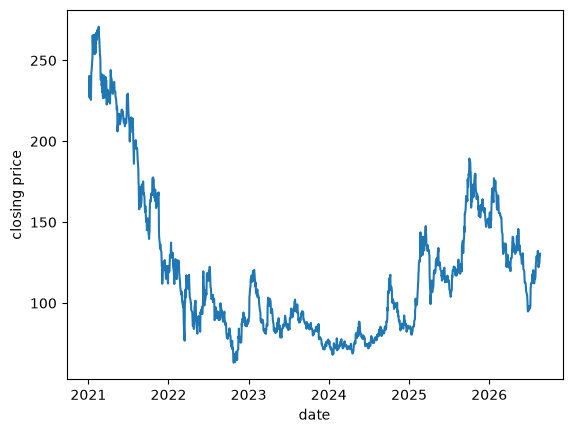

In [5]:
plt.plot(data)
plt.ylabel("closing price")
plt.xlabel("date")
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data["Close"])
print(result)
print(f"pvlaue is {result[1]} and AD statics is {result[0]}")

# pvalue >0.05, this is non stationary 


(np.float64(-2.527095827139193), np.float64(0.1090200270006183), 4, 1409, {'1%': np.float64(-3.434999576596685), '5%': np.float64(-2.8635934599975106), '10%': np.float64(-2.5678632530961614)}, np.float64(7545.967486317246))
pvlaue is 0.1090200270006183 and AD statics is -2.527095827139193


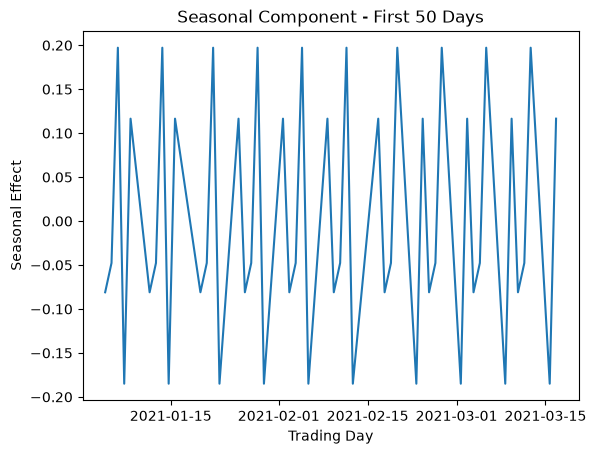

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(data, period = 5)
print(results)
plt.plot(results.seasonal[:50])
plt.title("Seasonal Component - First 50 Days")
plt.xlabel("Trading Day")
plt.ylabel("Seasonal Effect")
plt.show()

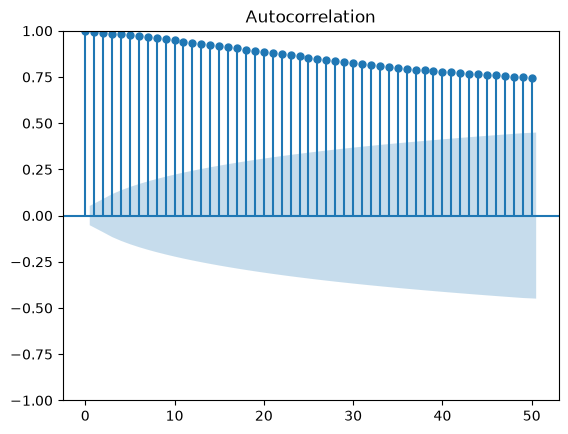

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(data, lags= 50 )
plt.show()

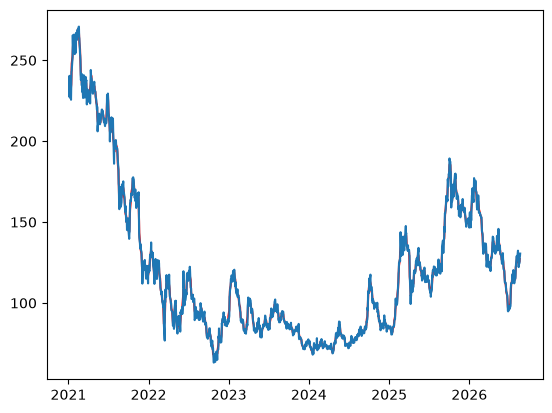

In [9]:
plt.plot(results.trend, c= "r")
plt.plot(data)
plt.show()

In [10]:
split= int(0.8*len(data))
x_train= data[:split]
x_test= data[split:]

print(x_train[:5])
print(x_test[:3])

                      Close
Date                       
2021-01-04 16:00:00  227.85
2021-01-05 16:00:00  240.40
2021-01-06 16:00:00  227.61
2021-01-07 16:00:00  226.90
2021-01-08 16:00:00  236.19
                      Close
Date                       
2025-07-08 16:00:00  107.99
2025-07-09 16:00:00  103.83
2025-07-10 16:00:00  106.64


In [11]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler(feature_range=(0, 1))

x_train_norm= scale.fit_transform(x_train)
print(x_train_norm[:4])
print(x_train_norm.shape)
x_test_norm = scale.transform(x_test)
print(x_test[:2])

[[0.793047  ]
 [0.8534765 ]
 [0.79189137]
 [0.78847265]]
(1131, 1)
                      Close
Date                       
2025-07-08 16:00:00  107.99
2025-07-09 16:00:00  103.83


In [12]:
# converting the shape of x_train to 3d  and crearing y_train for every 60 days consecutive day 

x_train_LSTM=[]
y_train_LSTM=[]

for i in range (60, len(x_train_norm)):
    x_train_LSTM.append(x_train_norm[i-60:i,0])
    y_train_LSTM.append(x_train_norm[i,0])


print(x_train_LSTM[:1])
print(y_train_LSTM[:1])


[array([0.793047  , 0.8534765 , 0.79189137, 0.78847265, 0.83320493,
       0.79073575, 0.78221302, 0.82891949, 0.86589946, 0.86821071,
       0.90764638, 0.97428737, 0.94785247, 0.94120763, 0.9544973 ,
       0.97635786, 0.94905624, 0.95151194, 0.9181433 , 0.97043529,
       0.92136941, 0.96436826, 0.98136556, 0.97515408, 0.96032357,
       0.97910247, 0.9853621 , 0.99085131, 0.985651  , 0.99937404,
       1.        , 0.96956857, 0.96513867, 0.91896186, 0.91294299,
       0.9013386 , 0.85241718, 0.84076464, 0.85968798, 0.8246822 ,
       0.83359014, 0.80580701, 0.8221302 , 0.78746148, 0.84259438,
       0.82410439, 0.85540254, 0.8124037 , 0.80474769, 0.7886171 ,
       0.8194819 , 0.83436055, 0.85053929, 0.83768297, 0.84033128,
       0.80142527, 0.76834553, 0.79020609, 0.81235555, 0.79978814])]
[np.float64(0.7876540832049306)]


In [13]:
x_train_LSTM=np.array(x_train_LSTM)
y_train_LSTM=np.array(y_train_LSTM)

print(x_train_LSTM[:2])
print(y_train_LSTM[:2])


print(x_train_LSTM.shape)
print(y_train_LSTM.shape)


x_train_LSTM = x_train_LSTM.reshape(
    x_train_LSTM.shape[0],
    x_train_LSTM.shape[1],1)


[[0.793047   0.8534765  0.79189137 0.78847265 0.83320493 0.79073575
  0.78221302 0.82891949 0.86589946 0.86821071 0.90764638 0.97428737
  0.94785247 0.94120763 0.9544973  0.97635786 0.94905624 0.95151194
  0.9181433  0.97043529 0.92136941 0.96436826 0.98136556 0.97515408
  0.96032357 0.97910247 0.9853621  0.99085131 0.985651   0.99937404
  1.         0.96956857 0.96513867 0.91896186 0.91294299 0.9013386
  0.85241718 0.84076464 0.85968798 0.8246822  0.83359014 0.80580701
  0.8221302  0.78746148 0.84259438 0.82410439 0.85540254 0.8124037
  0.80474769 0.7886171  0.8194819  0.83436055 0.85053929 0.83768297
  0.84033128 0.80142527 0.76834553 0.79020609 0.81235555 0.79978814]
 [0.8534765  0.79189137 0.78847265 0.83320493 0.79073575 0.78221302
  0.82891949 0.86589946 0.86821071 0.90764638 0.97428737 0.94785247
  0.94120763 0.9544973  0.97635786 0.94905624 0.95151194 0.9181433
  0.97043529 0.92136941 0.96436826 0.98136556 0.97515408 0.96032357
  0.97910247 0.9853621  0.99085131 0.985651   0.99

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


LSTM_model = Sequential()

LSTM_model.add(
            LSTM(
                120,
                activation="relu", 
                input_shape=(x_train_LSTM.shape[1], x_train_LSTM.shape[2])
            )
)
LSTM_model.add(Dropout(0.1)),
LSTM_model.add(Dense(64, activation="relu"))
LSTM_model.add(Dropout(0.1))
LSTM_model.add(Dense(1))

c:\Users\e_bab\Documents\4geeks\python-hello\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
from tensorflow.keras.optimizers import Adam

LSTM_model.compile(optimizer=Adam (learning_rate = 0.001), loss= "mse")

In [16]:
x_test_LSTM=[]
y_test_LSTM=[]

for i in range (60, len(x_test_norm)):
    x_test_LSTM.append(x_test_norm[i-60:i,0])
    y_test_LSTM.append(x_test_norm[i,0])

x_test_LSTM=np.array(x_test_LSTM)
y_test_LSTM=np.array(y_test_LSTM)

x_test_LSTM = x_test_LSTM.reshape(
    x_test_LSTM.shape[0],
    x_test_LSTM.shape[1],1)

print(x_test_LSTM.shape)
print(y_test_LSTM.shape)


(223, 60, 1)
(223,)


In [17]:
LSTM_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120)            │        58,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = LSTM_model.fit(x_train_LSTM, y_train_LSTM, epochs = 10, batch_size = 32)



Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0188
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0014
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011


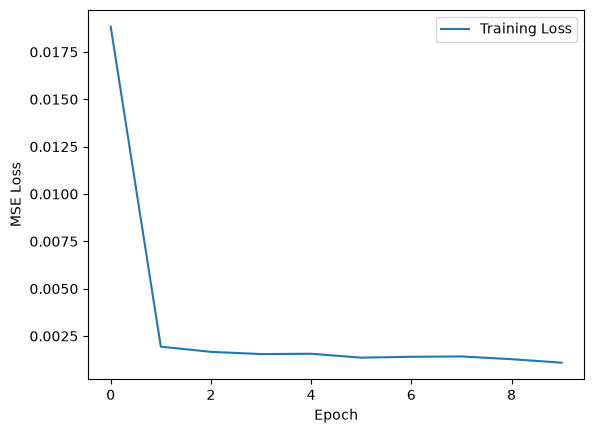

In [19]:
plt.plot(history.history["loss"], label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [20]:
test_loss = LSTM_model.evaluate(x_test_LSTM, y_test_LSTM)
y_pred= LSTM_model.predict(x_test_LSTM)
print(y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.9501e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.52703846]
 [0.5384579 ]
 [0.554827  ]
 [0.5660423 ]
 [0.5733574 ]
 [0.5704225 ]
 [0.56684226]
 [0.5531614 ]
 [0.52172637]
 [0.50710845]
 [0.49068862]
 [0.4825694 ]
 [0.47603822]
 [0.47449118]
 [0.4826705 ]
 [0.48101604]
 [0.4789695 ]
 [0.48569643]
 [0.49496692]
 [0.50837535]
 [0.5159051 ]
 [0.5257269 ]
 [0.52526486]
 [0.519514  ]
 [0.51066047]
 [0.49867886]
 [0.48975593]
 [0.48666096]
 [0.48291928]
 [0.47973895]
 [0.47070384]
 [0.45988274]
 [0.4542632 ]
 [0.44216466]
 [0.43832892]
 [0.43867463]
 [0.43849146]
 [0.43124187]
 [0.4252733 ]
 [0.43138927]
 [0.4317721 ]
 [0.43308747]
 [0.4338683 ]
 [0.4437294 ]
 [0.4476685 ]
 [0.44653916]
 [0.44448692]
 [0.44383347]
 [0.44295943]
 [0.43926543]
 [0.44014055]
 [0.43832934]
 [0.43526244]
 [0.42528576]
 [0.41628456]
 [0.40637475]
 [0.39916533]
 [0.39728063]
 [0.39796203]
 [0.39939243]
 [0.39933217]
 [0.4024579 ]
 [0.40007836]
 [0.39667994]
 [0.39296

In [21]:
y_pred_original = scale.inverse_transform(y_pred)
print(y_pred_original)

[[172.60535 ]
 [174.97693 ]
 [178.37646 ]
 [180.70566 ]
 [182.22487 ]
 [181.61534 ]
 [180.8718  ]
 [178.03055 ]
 [171.50214 ]
 [168.46628 ]
 [165.05621 ]
 [163.37001 ]
 [162.01361 ]
 [161.69232 ]
 [163.391   ]
 [163.04741 ]
 [162.62239 ]
 [164.01944 ]
 [165.94473 ]
 [168.72939 ]
 [170.29317 ]
 [172.33296 ]
 [172.237   ]
 [171.04268 ]
 [169.20396 ]
 [166.71562 ]
 [164.86252 ]
 [164.21974 ]
 [163.44267 ]
 [162.78218 ]
 [160.90578 ]
 [158.65845 ]
 [157.49138 ]
 [154.97876 ]
 [154.18214 ]
 [154.25395 ]
 [154.21591 ]
 [152.71031 ]
 [151.47076 ]
 [152.74092 ]
 [152.82043 ]
 [153.0936  ]
 [153.25577 ]
 [155.30373 ]
 [156.1218  ]
 [155.88725 ]
 [155.46104 ]
 [155.32533 ]
 [155.14381 ]
 [154.37665 ]
 [154.5584  ]
 [154.18224 ]
 [153.5453  ]
 [151.47334 ]
 [149.60397 ]
 [147.54591 ]
 [146.04866 ]
 [145.65724 ]
 [145.79875 ]
 [146.09583 ]
 [146.0833  ]
 [146.73245 ]
 [146.23827 ]
 [145.53249 ]
 [144.76001 ]
 [146.71371 ]
 [148.48697 ]
 [148.4067  ]
 [147.12306 ]
 [148.20847 ]
 [148.09605 ]
 [152.

In [22]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test_LSTM, y_pred)
mse = mean_squared_error(y_test_LSTM, y_pred)

print("R²:", r2)
print("MSE:", mse)

R²: 0.9291415333378261
MSE: 0.0007950060361704923


In [25]:
LSTM_model.save("lstm_model.keras")

from pickle import dump
dump(scale, open("scale_min_max.sav", "wb"))